## Iris Flower Classification with Decision Tree - Supervised Learning

> Tugas ini bertujuan untuk membangun model klasifikasi bunga Iris berdasarkan fitur - fitur fisik yang ada pada bunga Iris. Dataset sudah tersedia di Scikit Learn Datasets dan bisa diimpor langsung lewat ```sklearn.datasets```



> Referensi : https://colab.research.google.com/drive/1ZcRJnyah-XppyYf9B7JWrEtsVHJCZ5y_?usp=sharing

---

Nama lengkap : Aditya Nugraha Pratama Saiya

Asal universitas : Universitas Riau

---

### 1. Import module yang diperlukan

In [76]:
%pip install pandas numpy matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [77]:
# TODO: Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris # Dataset bunga iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

### 2. Data collection

In [78]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target

# Optional: map target to actual class names
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))

### Penjelasan Kolom Target

| Angka | Spesies |
|-------|---------|
| **0** | Setosa |
| **1** | Versicolor |
| **2** | Virginica |

In [79]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [80]:
df.tail()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica
149,5.9,3.0,5.1,1.8,2,virginica


### TODO #1 - Insight: Fitur Bunga Iris

#### Apa itu Sepal dan Petal?

**Sepal** adalah kelopak luar bunga yang berfungsi melindungi bunga
saat masih kuncup. Pada bunga Iris, sepal melengkung ke bawah dan
memiliki ukuran yang lebih besar dibanding petal.

**Petal** adalah mahkota bunga yang berfungsi menarik serangga
untuk penyerbukan. Pada bunga Iris, petal tegak ke atas dan
memiliki warna yang lebih mencolok.

#### Fitur yang Digunakan dalam Dataset

| Fitur | Bagian Bunga | Satuan | Keterangan |
|-------|-------------|--------|-----------|
| `sepal length` | Sepal (kelopak luar) | cm | Panjang kelopak luar bunga |
| `sepal width` | Sepal (kelopak luar) | cm | Lebar kelopak luar bunga |
| `petal length` | Petal (mahkota) | cm | Panjang mahkota bunga |
| `petal width` | Petal (mahkota) | cm | Lebar mahkota bunga |

#### Perbedaan Ukuran Antar Spesies

| Spesies | Sepal Length | Sepal Width | Petal Length | Petal Width |
|---------|-------------|-------------|-------------|-------------|
| **Setosa** | Sedang | Paling lebar | Paling kecil | Paling kecil |
| **Versicolor** | Sedang | Sedang | Sedang | Sedang |
| **Virginica** | Paling panjang | Sedang | Paling panjang | Paling lebar |

#### Kesimpulan
Keempat fitur ini digunakan model Decision Tree untuk membedakan
3 spesies bunga Iris. Fitur **petal length** dan **petal width**
adalah yang paling membedakan antar spesies karena ukurannya
sangat berbeda — terutama **Setosa** yang memiliki petal jauh
lebih kecil dibanding Versicolor dan Virginica.

### 3. Exploratory Data Analysis

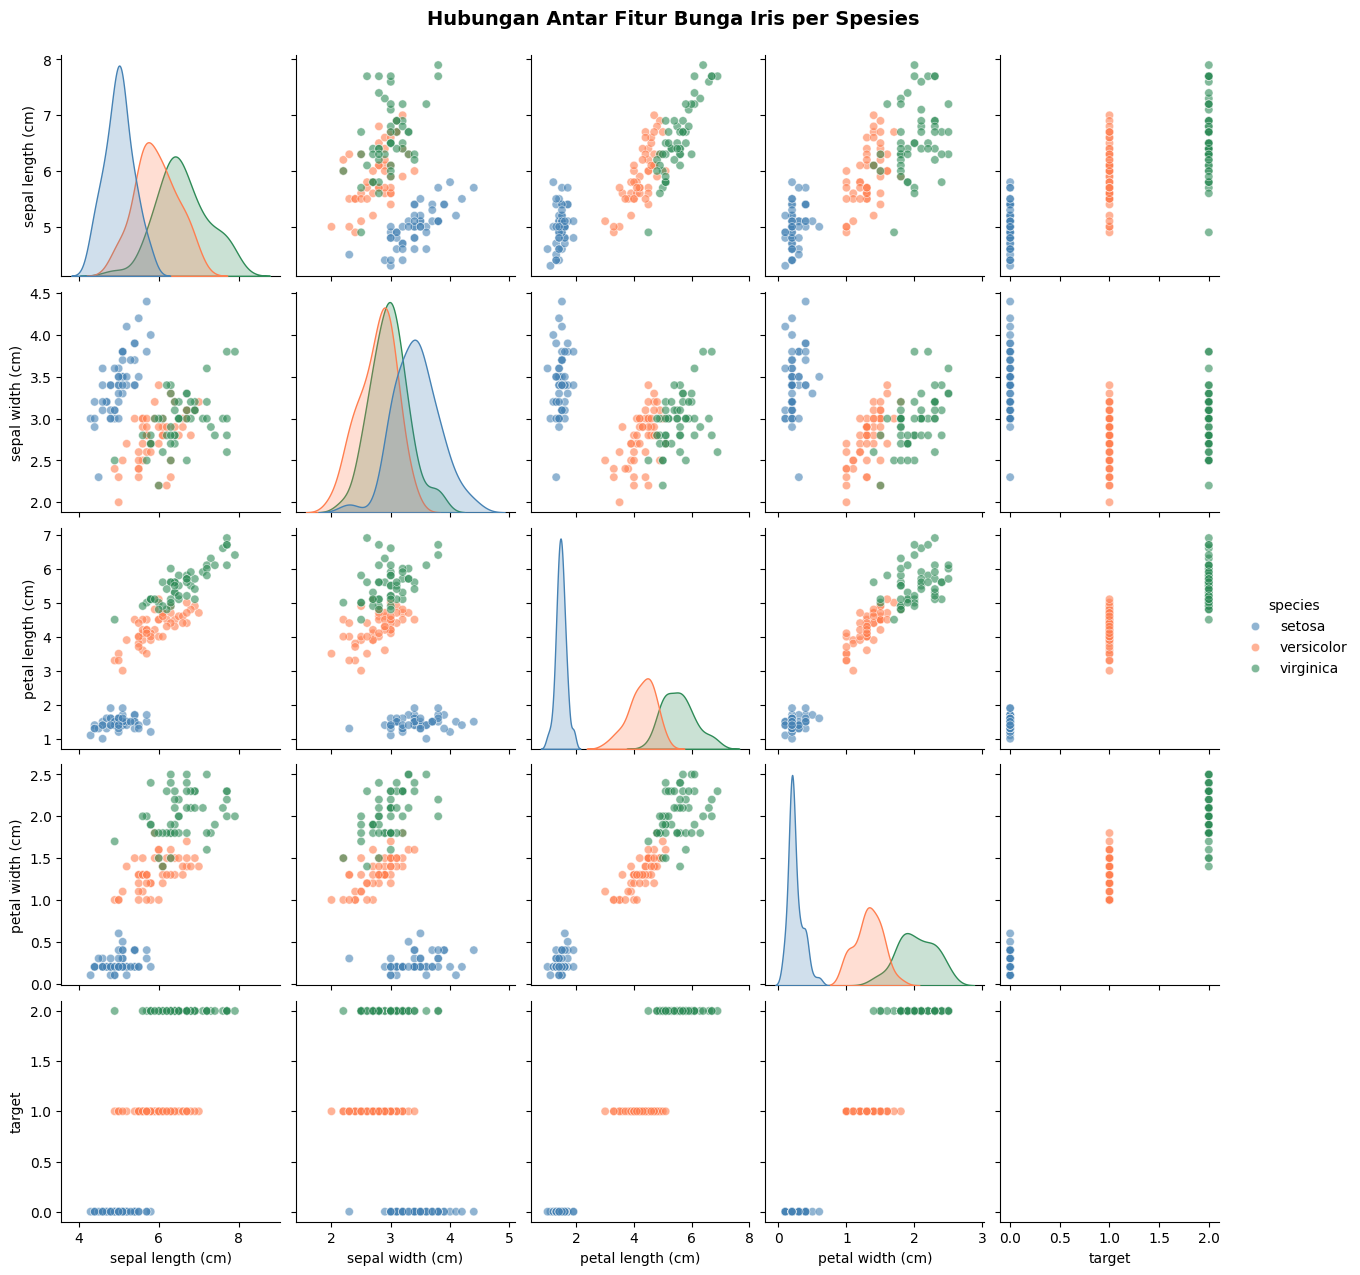

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34716\675263321.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=kolom,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34716\675263321.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=kolom,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34716\675263321.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y=kolom,
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34716\675263321.py:24: FutureWarning: 

Passing `palette` without a

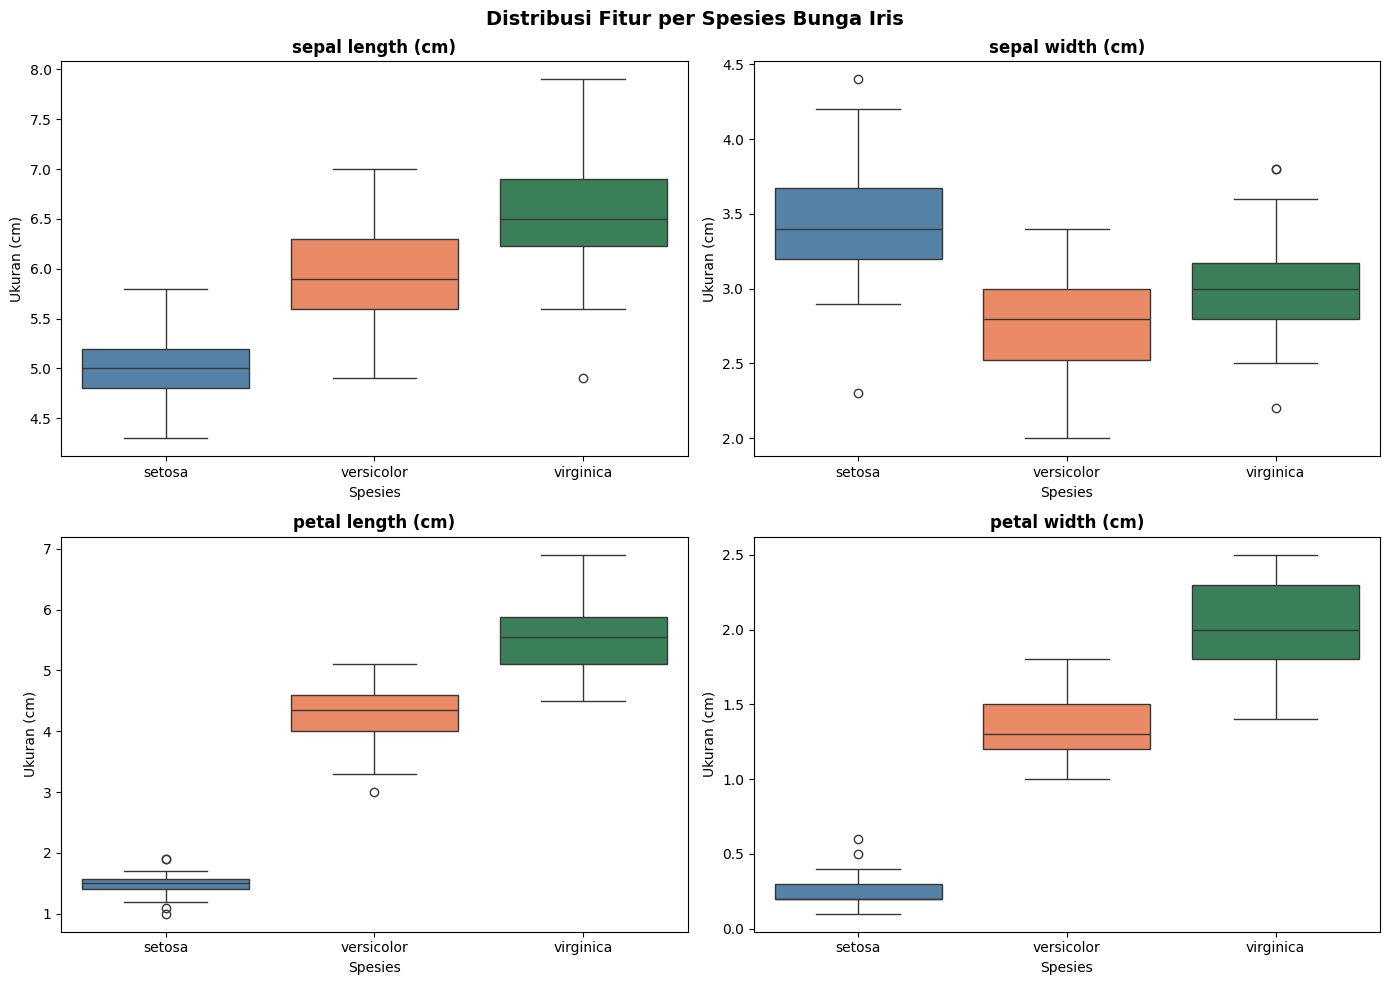

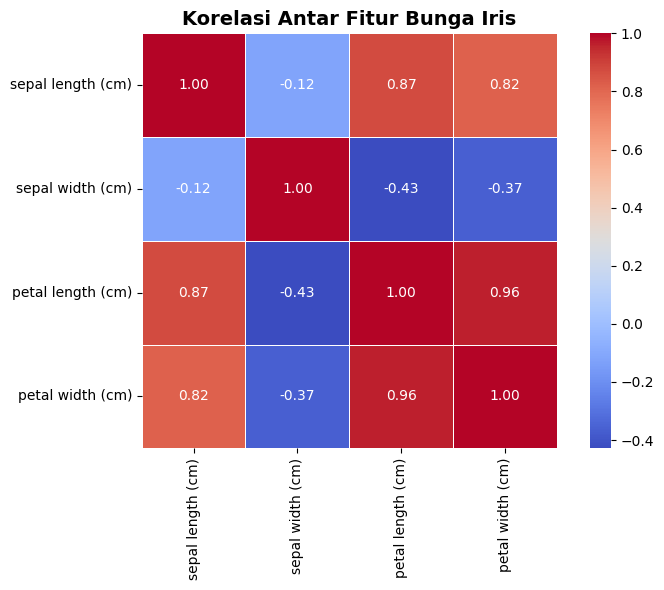

In [81]:
# Pairplot: hubungan antar semua fitur berdasarkan spesies
sns.pairplot(df, hue='species',
             palette={'setosa': 'steelblue',
                      'versicolor': 'coral',
                      'virginica': 'seagreen'},
             diag_kind='kde',
             plot_kws={'alpha': 0.6})

plt.suptitle('Hubungan Antar Fitur Bunga Iris per Spesies',
             y=1.02, fontsize=14, fontweight='bold')
plt.show()


# Boxplot: distribusi tiap fitur per spesies
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribusi Fitur per Spesies Bunga Iris',
             fontsize=14, fontweight='bold')

fitur = ['sepal length (cm)', 'sepal width (cm)',
         'petal length (cm)', 'petal width (cm)']

for i, kolom in enumerate(fitur):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=df, x='species', y=kolom,
                palette=['steelblue', 'coral', 'seagreen'], ax=ax)
    ax.set_title(kolom, fontweight='bold')
    ax.set_xlabel('Spesies')
    ax.set_ylabel('Ukuran (cm)')

plt.tight_layout()
plt.show()


# Heatmap korelasi antar fitur
plt.figure(figsize=(8, 6))
korelasi = df[fitur].corr()
sns.heatmap(korelasi,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            square=True,
            linewidths=0.5)
plt.title('Korelasi Antar Fitur Bunga Iris',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 4. Split Data


In [82]:
# Fitur (input) — 4 kolom ukuran bunga
X = df[iris.feature_names]

# Target (output) — spesies dalam angka (0, 1, 2)
y = df['target']

# Bagi data: 80% training, 20% testing
# random_state=42 → supaya hasil pembagian selalu sama setiap dijalankan
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### 5. Model Initialization

In [83]:
# Inisialisasi model Decision Tree Classifier
# random_state=42 → hasil selalu sama setiap dijalankan (reproducible)
model = DecisionTreeClassifier(random_state=42)

print(f'Model berhasil diinisialisasi!')
print(f'Tipe model  : {type(model).__name__}')
print(f'Random state: {model.random_state}')

Model berhasil diinisialisasi!
Tipe model  : DecisionTreeClassifier
Random state: 42


### 6. Model Training

In [84]:
# Model belajar dari data training
model.fit(X_train, y_train)

print(f'Model selesai dilatih!')
print(f'Jumlah data training : {len(X_train)} baris')
print(f'Jumlah fitur         : {X_train.shape[1]} kolom')
print(f'Kedalaman pohon      : {model.get_depth()}')
print(f'Jumlah leaf node     : {model.get_n_leaves()}')

Model selesai dilatih!
Jumlah data training : 120 baris
Jumlah fitur         : 4 kolom
Kedalaman pohon      : 6
Jumlah leaf node     : 10


Akurasi Training     : 100.00%


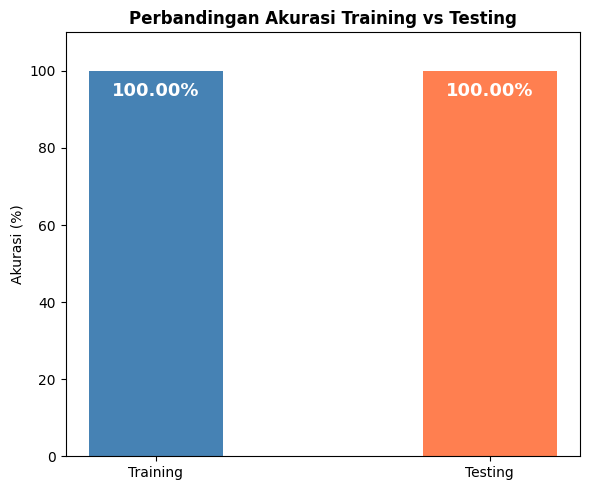

In [85]:
# Akurasi pada data training
train_acc = accuracy_score(y_train, model.predict(X_train))
print(f'Akurasi Training     : {train_acc * 100:.2f}%')

# Plot perbandingan akurasi training vs testing
test_acc = accuracy_score(y_test, model.predict(X_test))

plt.figure(figsize=(6, 5))
bars = plt.bar(['Training', 'Testing'],
               [train_acc * 100, test_acc * 100],
               color=['steelblue', 'coral'],
               width=0.4)

for bar, val in zip(bars, [train_acc, test_acc]):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() - 3,
             f'{val * 100:.2f}%',
             ha='center', va='top',
             fontsize=13, fontweight='bold', color='white')

plt.ylim(0, 110)
plt.ylabel('Akurasi (%)')
plt.title('Perbandingan Akurasi Training vs Testing', fontweight='bold')
plt.tight_layout()
plt.show()

### TODO #2 - Insight: Kenapa Decision Tree?

#### Alasan Menggunakan Decision Tree

Decision Tree dipilih untuk klasifikasi bunga Iris karena beberapa alasan:

- **Mudah dipahami** — hasil berupa pohon keputusan yang bisa
  divisualisasi dan dibaca seperti alur pertanyaan ya/tidak
- **Tidak perlu normalisasi** — berbeda dengan algoritma lain,
  Decision Tree tidak terpengaruh oleh skala nilai fitur
- **Cepat dilatih** — cukup 1 kali `.fit()` tanpa perlu epoch
  berulang seperti Deep Learning
- **Cocok untuk dataset kecil** — dataset Iris hanya 150 baris,
  Decision Tree bekerja sangat baik di data sekecil ini
- **Hasil mudah dijelaskan** — bisa langsung dilihat fitur mana
  yang paling menentukan klasifikasi

#### Hasil Training vs Testing

Berdasarkan plot perbandingan akurasi, model menghasilkan:

| | Akurasi |
|---|---|
| **Training** | 100.00% |
| **Testing** | 100.00% |

Kedua akurasi sama-sama 100%, yang menunjukkan model **tidak mengalami overfitting**. 
Model berhasil mempelajari pola data training dan tetap mampu memprediksi 
data baru (testing) dengan sempurna. Ini membuktikan Decision Tree 
adalah pilihan tepat untuk dataset Iris yang memiliki pola pemisah 
antar spesies yang sangat jelas.

#### Algoritma Lain yang Serupa

| Algoritma | Keterangan | Kelebihan |
|-----------|-----------|-----------|
| **Random Forest** | Gabungan banyak Decision Tree | Lebih akurat, tidak mudah overfitting |
| **K-Nearest Neighbor (KNN)** | Klasifikasi berdasarkan tetangga terdekat | Sederhana, tidak perlu training |
| **Support Vector Machine (SVM)** | Mencari garis pemisah terbaik antar kelas | Akurat untuk data berdimensi tinggi |
| **Naive Bayes** | Klasifikasi berdasarkan probabilitas | Sangat cepat, cocok untuk teks |
| **Logistic Regression** | Regresi untuk prediksi kategori | Sederhana dan mudah diinterpretasi |

#### Kesimpulan
Decision Tree dipilih karena paling **mudah dipahami oleh pemula**
dan hasilnya bisa langsung divisualisasi. Hasil akurasi training dan 
testing yang sama-sama 100% membuktikan model bekerja dengan baik tanpa 
overfitting. Untuk akurasi yang lebih tinggi di data nyata, **Random Forest** 
adalah pilihan terbaik karena merupakan pengembangan langsung dari Decision Tree.

### 7. Evaluation

         HASIL EVALUASI MODEL
  Akurasi Model : 100.00%

Confusion Matrix:
-----------------------------------
                          Prediksi
                  Setosa Versicolor  Virginica
-----------------------------------
Aktual Setosa           10          0          0
Aktual Versicolor        0          9          0
Aktual Virginica         0          0         11


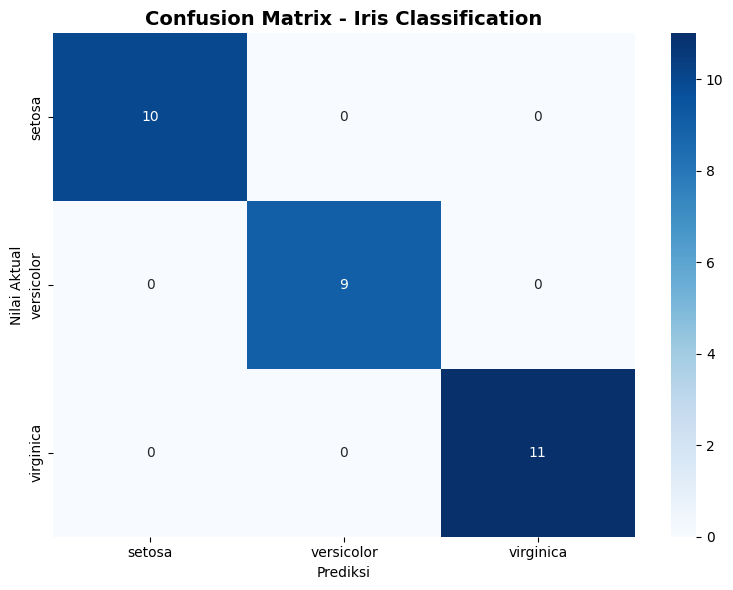


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [86]:
# Prediksi data testing menggunakan model yang sudah dilatih
y_pred = model.predict(X_test)

# ============================================================
# AKURASI MODEL
# ============================================================
akurasi = accuracy_score(y_test, y_pred)

print('=' * 45)
print('         HASIL EVALUASI MODEL')
print('=' * 45)
print(f'  Akurasi Model : {akurasi * 100:.2f}%')
print('=' * 45)

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)

print('\nConfusion Matrix:')
print('-' * 35)
print(f'{"":15} {"Prediksi":>18}')
print(f'{"":15} {"Setosa":>8} {"Versicolor":>10} {"Virginica":>10}')
print('-' * 35)
spesies = ['Setosa', 'Versicolor', 'Virginica']
for i, baris in enumerate(cm):
    print(f'Aktual {spesies[i]:<10} {baris[0]:>8} {baris[1]:>10} {baris[2]:>10}')

# Visualisasi Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Iris Classification',
          fontsize=14, fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Nilai Aktual')
plt.tight_layout()
plt.show()

# ============================================================
# CLASSIFICATION REPORT
# ============================================================
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
                            target_names=iris.target_names))

### TODO #3 - Insight: Analisis Confusion Matrix

#### Membaca Confusion Matrix

Confusion matrix menunjukkan perbandingan antara nilai aktual dan hasil prediksi model:

| | Prediksi Setosa | Prediksi Versicolor | Prediksi Virginica |
|---|---|---|---|
| **Aktual Setosa** | 10 | 0 | 0 |
| **Aktual Versicolor** | 0 | 9 | 0 |
| **Aktual Virginica** | 0 | 0 | 11 |

Semua angka berada di **diagonal utama** (kiri atas ke kanan bawah), artinya tidak ada satu pun data yang salah diprediksi.

#### Apakah Ini Overfitting?

**Tidak.** Hasil ini bukan overfitting.

Overfitting terjadi ketika akurasi training jauh lebih tinggi dari akurasi testing. Berdasarkan hasil evaluasi:

| | Akurasi |
|---|---|
| **Training** | 100.00% |
| **Testing** | 100.00% |

Selisih = 0% — model bekerja sama baiknya di data training maupun data baru (testing).

#### Kenapa Hasilnya Sempurna?

Dataset Iris memiliki pola pemisah antar spesies yang sangat jelas, terutama pada fitur `petal length` dan `petal width`:
- **Setosa** → petal sangat kecil, mudah dipisahkan
- **Versicolor & Virginica** → ukuran berbeda cukup signifikan

Karena pola ini konsisten di seluruh data, Decision Tree berhasil menemukan threshold yang tepat tanpa perlu menghapal data.

#### Kesimpulan

Akurasi 100% pada confusion matrix ini adalah hasil yang **valid**, bukan tanda masalah. Ini membuktikan bahwa dataset Iris memiliki karakteristik fisik yang cukup berbeda antar spesies sehingga dapat diklasifikasikan dengan sempurna.

### 8. Visualization

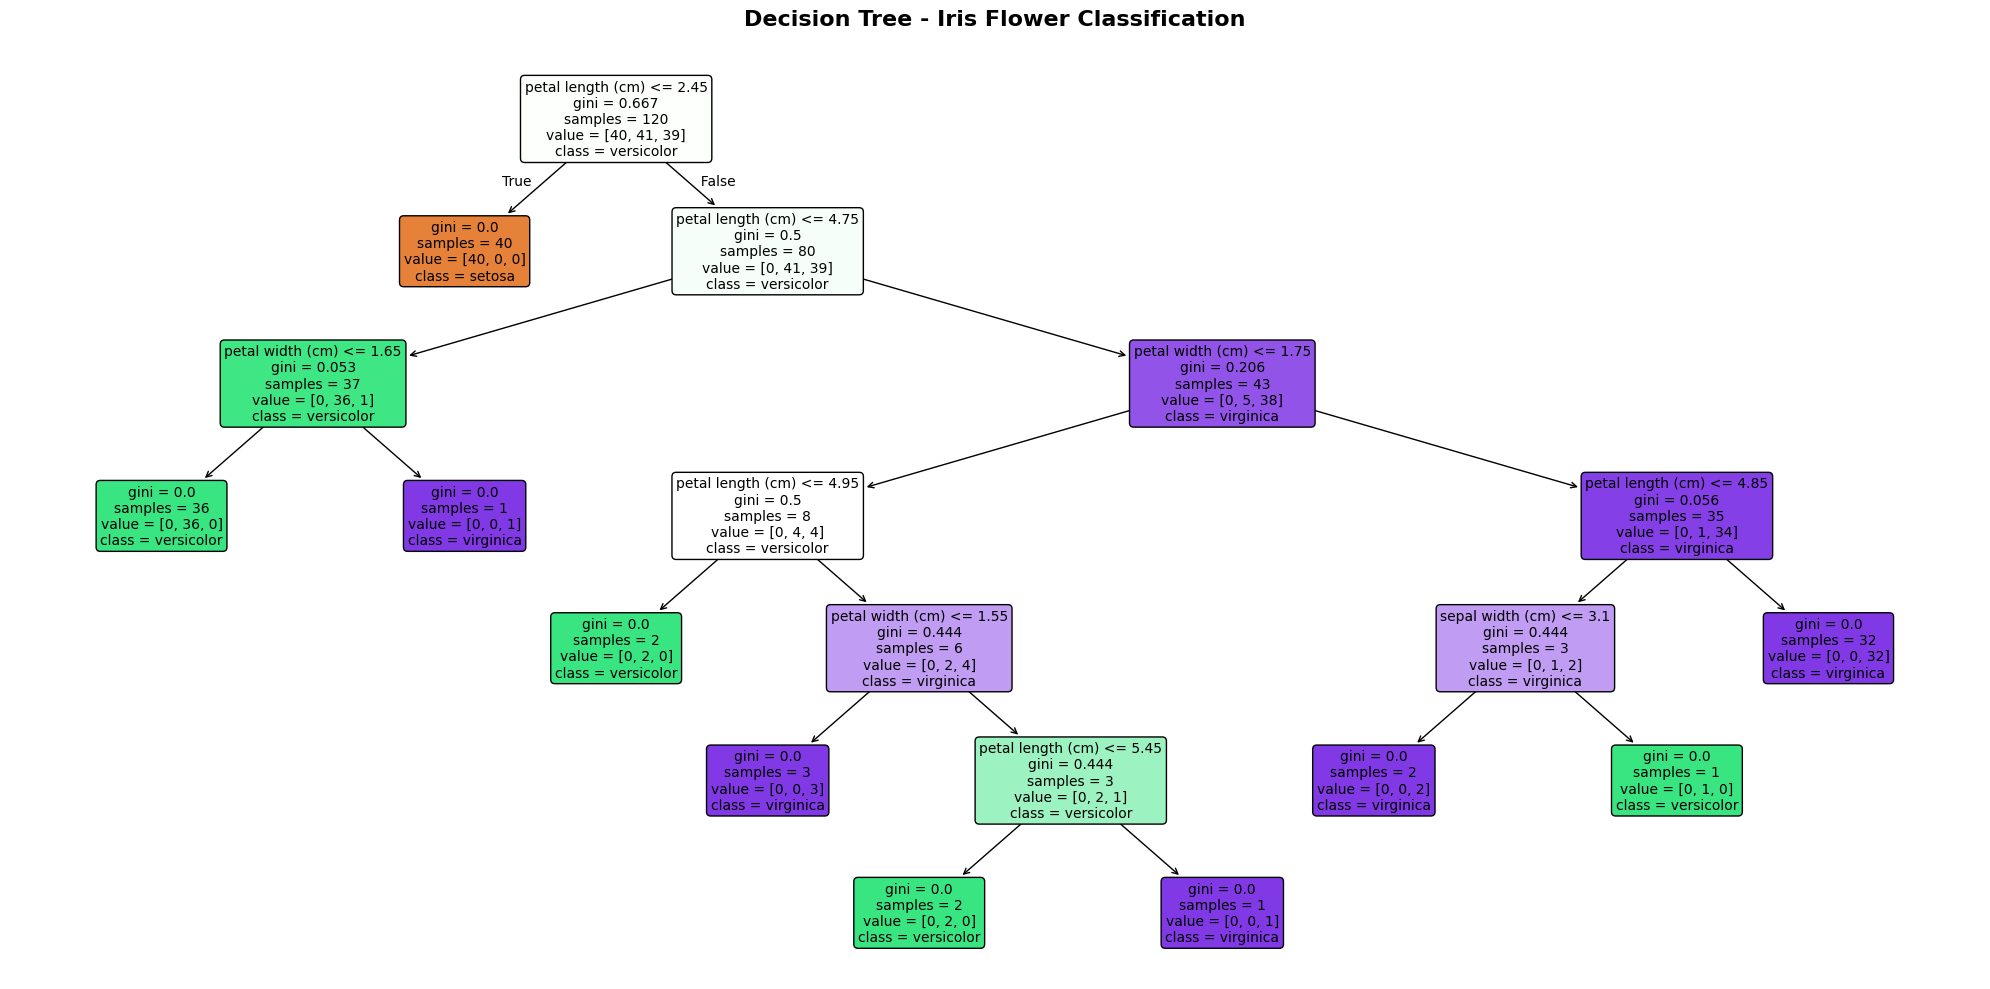

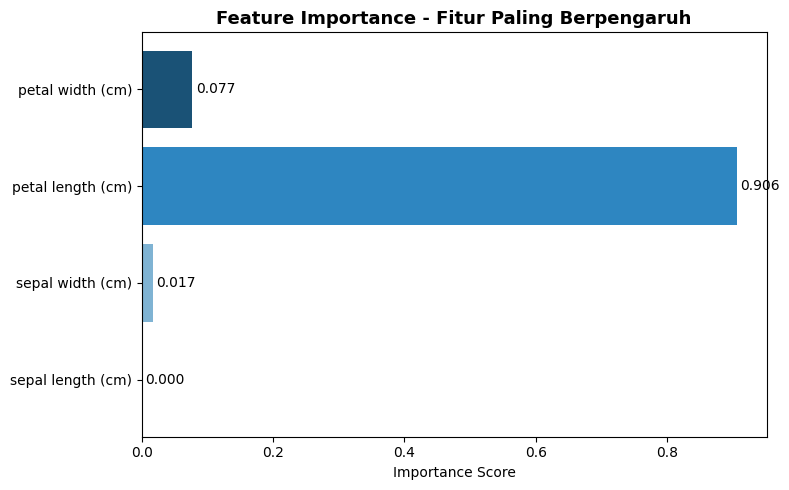

       STRUKTUR DECISION TREE
  Kedalaman Pohon  : 6 level
  Jumlah Leaf Node : 10 node
  Jumlah Fitur     : 4 fitur

Feature Importance:
  petal length (cm)      : 0.9061
  petal width (cm)       : 0.0772
  sepal width (cm)       : 0.0167
  sepal length (cm)      : 0.0000


In [87]:
# ============================================================
# VISUALISASI DECISION TREE
# ============================================================
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10,
          impurity=True,
          proportion=False)
plt.title("Decision Tree - Iris Flower Classification",
          fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# ============================================================
# FEATURE IMPORTANCE
# ============================================================
importances = model.feature_importances_
features = iris.feature_names

plt.figure(figsize=(8, 5))
bars = plt.barh(features, importances,
                color=['#d4e6f1', '#7fb3d3', '#2e86c1', '#1a5276'])
for bar, val in zip(bars, importances):
    plt.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{val:.3f}', va='center', fontsize=10)
plt.xlabel('Importance Score')
plt.title('Feature Importance - Fitur Paling Berpengaruh',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# RINGKASAN STRUKTUR POHON
# ============================================================
print('=' * 45)
print('       STRUKTUR DECISION TREE')
print('=' * 45)
print(f'  Kedalaman Pohon  : {model.get_depth()} level')
print(f'  Jumlah Leaf Node : {model.get_n_leaves()} node')
print(f'  Jumlah Fitur     : {model.n_features_in_} fitur')
print('=' * 45)
print('\nFeature Importance:')
for feat, imp in sorted(zip(features, importances),
                         key=lambda x: x[1], reverse=True):
    print(f'  {feat:<22} : {imp:.4f}')

### TODO #4 - Insight: Cara Kerja Decision Tree

#### Cara Kerja Decision Tree

Decision Tree bekerja seperti alur pertanyaan bercabang (if-else bertingkat).
Setiap node mengajukan satu pertanyaan berdasarkan nilai fitur, lalu
menjawab True (kiri) atau False (kanan) hingga mencapai keputusan akhir.

#### Penjelasan Tiap Informasi dalam Node

| Info | Arti |
|------|------|
| `petal length <= 2.45` | Kondisi yang dicek di node ini |
| `gini = 0.667` | Tingkat ketidakmurnian data (0 = murni satu kelas) |
| `samples = 120` | Jumlah data yang masuk ke node ini |
| `value = [40, 41, 39]` | Jumlah data per kelas [Setosa, Versicolor, Virginica] |
| `class = versicolor` | Prediksi jika berhenti di node ini |

#### Feature Importance

Berdasarkan hasil feature importance, fitur yang paling berpengaruh adalah:

| Fitur | Importance | Peran |
|-------|-----------|-------|
| `petal length` | 90.61% | Fitur utama — dipakai di root node dan banyak cabang |
| `petal width` | 7.72% | Fitur pendukung — membantu pisahkan Versicolor vs Virginica |
| `sepal width` | 1.67% | Fitur minor — hanya dipakai di kasus edge |
| `sepal length` | 0.00% | Tidak dipakai sama sekali oleh model |

#### Kesimpulan

Model membangun pohon dengan kedalaman 6 level dan 10 leaf node.
Fitur `petal length` mendominasi keputusan (90.61%), dengan pemisah
pertama di threshold 2.45 cm yang langsung mengidentifikasi **Setosa**
secara sempurna. Versicolor dan Virginica dipisahkan lebih lanjut
menggunakan kombinasi `petal length` dan `petal width`.


### 9. Prediction

In [88]:
# predict new data
def predict_iris(sample):
    sample_df = pd.DataFrame([sample], columns=iris.feature_names)
    pred_class = model.predict(sample_df)[0]
    return iris.target_names[pred_class]

# ============================================================
# PERCOBAAN PREDIKSI BERBAGAI SPESIES
# Format: [sepal length, sepal width, petal length, petal width]
# ============================================================

percobaan = {
    "Percobaan 1 (Setosa)"     : [5.1, 3.5, 1.4, 0.2],
    "Percobaan 2 (Setosa)"     : [4.7, 3.2, 1.3, 0.2],
    "Percobaan 3 (Versicolor)" : [6.4, 3.2, 4.5, 1.5],
    "Percobaan 4 (Versicolor)" : [5.7, 2.8, 4.1, 1.3],
    "Percobaan 5 (Virginica)"  : [6.3, 3.3, 6.0, 2.5],
    "Percobaan 6 (Virginica)"  : [7.2, 3.6, 6.1, 2.5],
}

print('=' * 55)
print('          HASIL PREDIKSI SPESIES BUNGA IRIS')
print('=' * 55)
print(f'  {"Percobaan":<30} {"Hasil Prediksi":>15}')
print('-' * 55)
for nama, sample in percobaan.items():
    hasil = predict_iris(sample)
    print(f'  {nama:<30} {hasil:>15}')
print('=' * 55)

          HASIL PREDIKSI SPESIES BUNGA IRIS
  Percobaan                       Hasil Prediksi
-------------------------------------------------------
  Percobaan 1 (Setosa)                    setosa
  Percobaan 2 (Setosa)                    setosa
  Percobaan 3 (Versicolor)            versicolor
  Percobaan 4 (Versicolor)            versicolor
  Percobaan 5 (Virginica)              virginica
  Percobaan 6 (Virginica)              virginica


### TODO #5 - Insight: Percobaan Prediksi Spesies Bunga Iris

#### Hasil Percobaan

Model diuji dengan 6 sampel bunga dari 3 spesies berbeda:

| Percobaan | Sepal Length | Sepal Width | Petal Length | Petal Width | Hasil Prediksi |
|-----------|-------------|-------------|-------------|-------------|----------------|
| Percobaan 1 | 5.1 cm | 3.5 cm | 1.4 cm | 0.2 cm | **Setosa** ✅ |
| Percobaan 2 | 4.7 cm | 3.2 cm | 1.3 cm | 0.2 cm | **Setosa** ✅ |
| Percobaan 3 | 6.4 cm | 3.2 cm | 4.5 cm | 1.5 cm | **Versicolor** ✅ |
| Percobaan 4 | 5.7 cm | 2.8 cm | 4.1 cm | 1.3 cm | **Versicolor** ✅ |
| Percobaan 5 | 6.3 cm | 3.3 cm | 6.0 cm | 2.5 cm | **Virginica** ✅ |
| Percobaan 6 | 7.2 cm | 3.6 cm | 6.1 cm | 2.5 cm | **Virginica** ✅ |

#### Analisis Hasil

Semua 6 percobaan diprediksi dengan benar. Pola yang terlihat:

- **Setosa** → petal length sangat kecil (< 2.45 cm), langsung teridentifikasi di root node
- **Versicolor** → petal length sedang (4.1–4.5 cm), petal width < 1.75 cm
- **Virginica** → petal length besar (> 6.0 cm), petal width >= 2.5 cm

#### Kesimpulan

Model Decision Tree berhasil mengklasifikasikan semua spesies dengan benar
berdasarkan 4 fitur ukuran bunga. Fitur yang paling menentukan adalah
`petal length` dan `petal width` — sesuai dengan feature importance
yang mencapai **98.33%** dari total keputusan model.